In [2]:
import os 
import matplotlib as mpl

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64" 

mpl.rcParams.update({ "text.usetex": True, "font.family": "serif", "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}" }) 

os.chdir(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code")

In [3]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"
global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [4]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star For

In [5]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

In [6]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

In [7]:
fits = []

for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 2,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500,
                            global_max + 500,
                            5.),
    )

    flux_lambda = np.array(model.photometry)   # erg/s/cm^2/Å

    # effective wavelengths in Å
    filter_wavelengths = []

    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)

    filter_wavelengths = np.array(filter_wavelengths)

    # Convert F_lambda -> F_nu (µJy)
    c = 2.99792458e18  # speed of light in Å/s

    flux_nu = flux_lambda * (filter_wavelengths**2) / c
    flux_nu = flux_nu / 1e-23      # convert to Jy
    flux_nu = flux_nu * 1e6        # Jy -> µJy

    fluxes = flux_nu
    fluxes_error = fluxes / 10.0

    galaxy_photometry = np.c_[fluxes, fluxes_error]

    def load_synthetic(ID):
        return galaxy_photometry

    galaxy = pipes.galaxy(
        f"age_{t:.2f}Gyr_exp",
        load_synthetic,
        spectrum_exists=False,
        photometry_exists=True,
        filt_list=filter_files
    )

    fit_info = {
        "redshift": 2.0,
        "exponential": {
            "massformed": (5., 12.),
            "metallicity": (0.0001, 2.),
            "metallicity_prior": "log_10",
            "age": (0.001, 1.0),
            "tau": (0.001, 5.)
        },
        "dust": {
            "type": "Calzetti",
            "Av": (0., 2.),
            "eta": (2)
        },
        "nebular": {
            "logU": (-4., -2.)
        }
    }

    fit = pipes.fit(galaxy, fit_info, run="exponential/z_2")
    fit.fit(verbose=True)

    fits.append(fit)
    print(f"Finished fitting age {t} Gyr")


Results loaded from pipes/posterior/exponential/z_2/age_0.00Gyr_exp.h5

Fitting not performed as results have already been loaded from pipes/posterior/exponential/z_2/age_0.00Gyr_exp.h5. To start over delete this file or change run.

Finished fitting age 0.0 Gyr

Results loaded from pipes/posterior/exponential/z_2/age_0.01Gyr_exp.h5

Fitting not performed as results have already been loaded from pipes/posterior/exponential/z_2/age_0.01Gyr_exp.h5. To start over delete this file or change run.

Finished fitting age 0.01 Gyr

Results loaded from pipes/posterior/exponential/z_2/age_0.02Gyr_exp.h5

Fitting not performed as results have already been loaded from pipes/posterior/exponential/z_2/age_0.02Gyr_exp.h5. To start over delete this file or change run.

Finished fitting age 0.02 Gyr

Results loaded from pipes/posterior/exponential/z_2/age_0.03Gyr_exp.h5

Fitting not performed as results have already been loaded from pipes/posterior/exponential/z_2/age_0.03Gyr_exp.h5. To start over dele

### Plotting fit SFH

In [8]:
import numpy as np
from bagpipes import utils

# redshift
if "redshift" in fit.fitted_model.params:
    redshift = np.median(fit.posterior.samples["redshift"])
else:
    redshift = fit.fitted_model.model_components["redshift"]

age_of_universe = np.interp(redshift, utils.z_array, utils.age_at_z)

# SFH posterior
post = np.percentile(fit.posterior.samples["sfh"], (16, 50, 84), axis=0).T

x = age_of_universe - fit.posterior.sfh.ages * 1e-9
median_sfr = post[:,1]
lower_sfr = post[:,0]
upper_sfr = post[:,2]

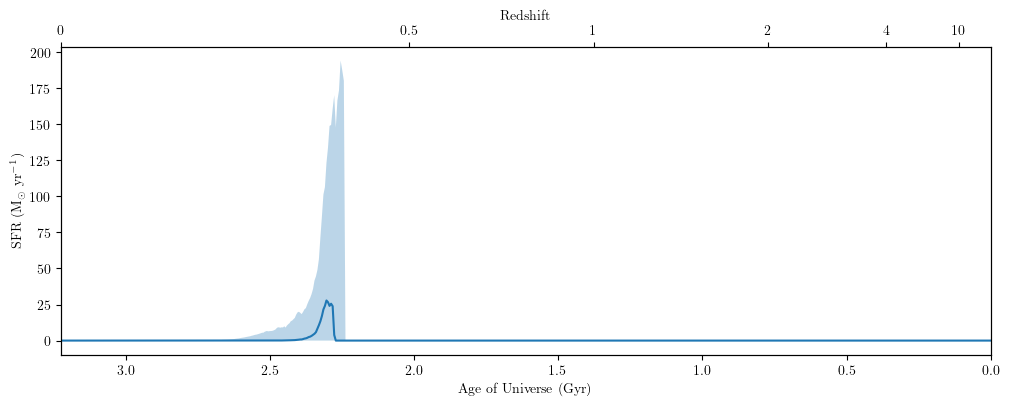

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(x, median_sfr)
ax.fill_between(x, lower_sfr, upper_sfr, alpha=0.3)

ax.set_xlim(max(x),0)
ax.set_xlabel("Age of Universe (Gyr)")
ax.set_ylabel("SFR (M$_\odot$ yr$^{-1}$)")

ax_top = ax.twiny()

zvals = [0,0.5,1,2,4,10]
ages = np.interp(zvals, utils.z_array, utils.age_at_z)

ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(ages)
ax_top.set_xticklabels(zvals)
ax_top.set_xlabel("Redshift")

plt.show()

### Plotting model SFH

In [10]:
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

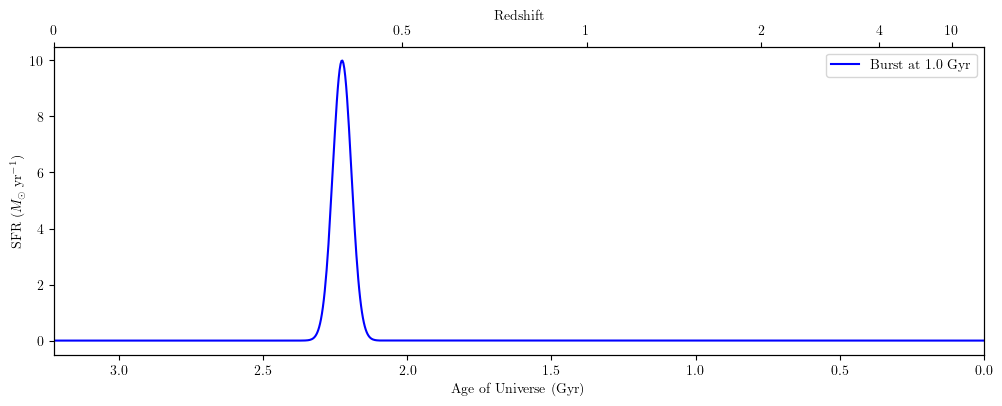

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

# Model parameters
burst_age = 1.0         
z_model = 2               
massformed = 10           
metallicity = 0.5

# Age of universe at z=2
age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)  # ~3.3 Gyr

# time array for SFH plotting
n_bins = 1000
ages_array = np.linspace(0, age_of_universe, n_bins) 

# Adaptive sigma: 1% of total SFH duration
sigma = (ages_array.max() - ages_array.min()) * 0.01 

burst_center = age_of_universe - burst_age
sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(ages_array, sfr_array, color="blue", label=f"Burst at {burst_age} Gyr")

ax.set_xlim(age_of_universe, 0)

ax.set_xlabel("Age of Universe (Gyr)")
ax.set_ylabel(r"SFR ($M_\odot\,\mathrm{yr}^{-1}$)")
ax.legend()

ax_top = ax.twiny()
zvals = [0,0.5,1,2,4,10]
ages_top = np.interp(zvals, utils.z_array, utils.age_at_z)
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(ages_top)
ax_top.set_xticklabels(zvals)
ax_top.set_xlabel("Redshift")

plt.show()

### Overlaying plots of model and posterior SFHs

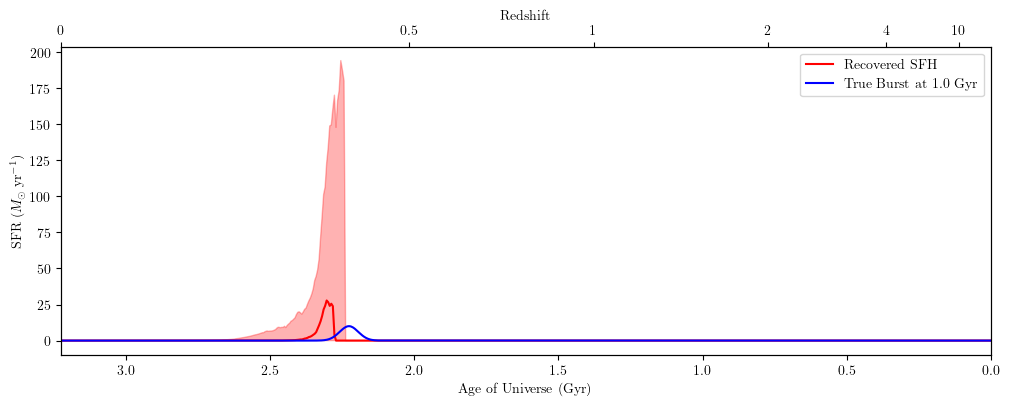

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

fig, ax = plt.subplots(figsize=(12,4))

# Recovered SFH posterior
ax.plot(x, median_sfr, color="red", label="Recovered SFH")
ax.fill_between(x, lower_sfr, upper_sfr, color="red", alpha=0.3)

# synthetic burst SFH
# Model parameters
burst_age = 1.0        
z_model = 2
massformed = 10

age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)

n_bins = 1000
ages_array = np.linspace(0, age_of_universe, n_bins)

# Adaptive sigma (1% of total duration)
sigma = (ages_array.max() - ages_array.min()) * 0.01
burst_center = age_of_universe - burst_age
sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))

# Plot synthetic burst
ax.plot(ages_array, sfr_array, color="blue", label=f"True Burst at {burst_age} Gyr")

ax.set_xlim(age_of_universe, 0) 
ax.set_xlabel("Age of Universe (Gyr)")
ax.set_ylabel(r"SFR ($M_\odot\,\mathrm{yr}^{-1}$)")
ax.legend()

ax_top = ax.twiny()
zvals = [0,0.5,1,2,4,10]
ages_top = np.interp(zvals, utils.z_array, utils.age_at_z)
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(ages_top)
ax_top.set_xticklabels(zvals)
ax_top.set_xlabel("Redshift")

plt.show()

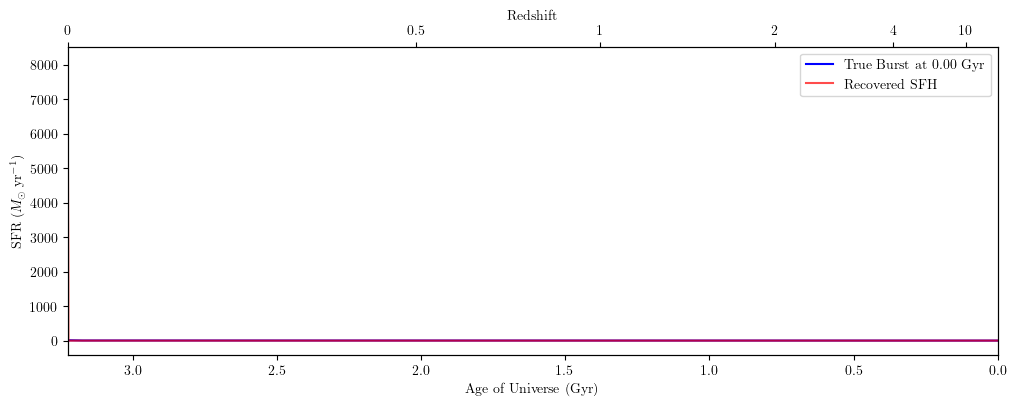

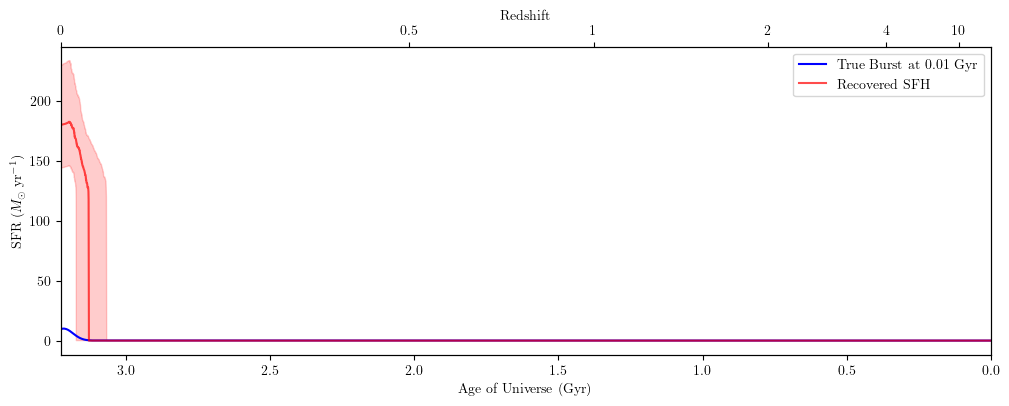

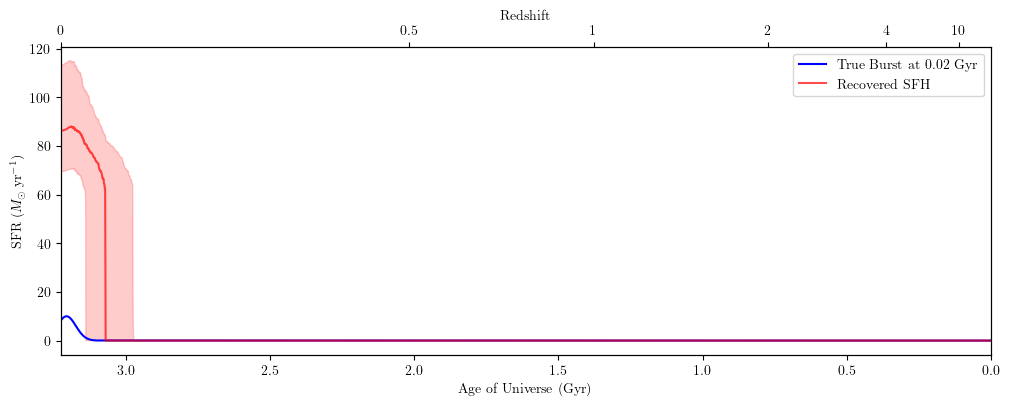

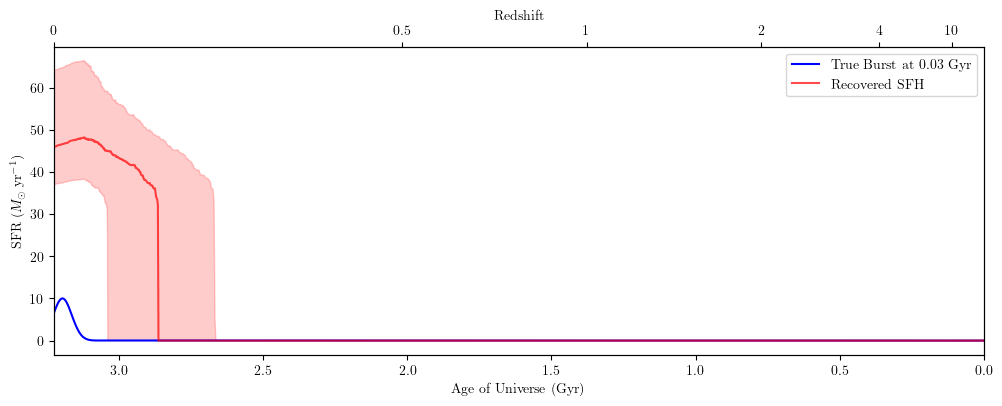

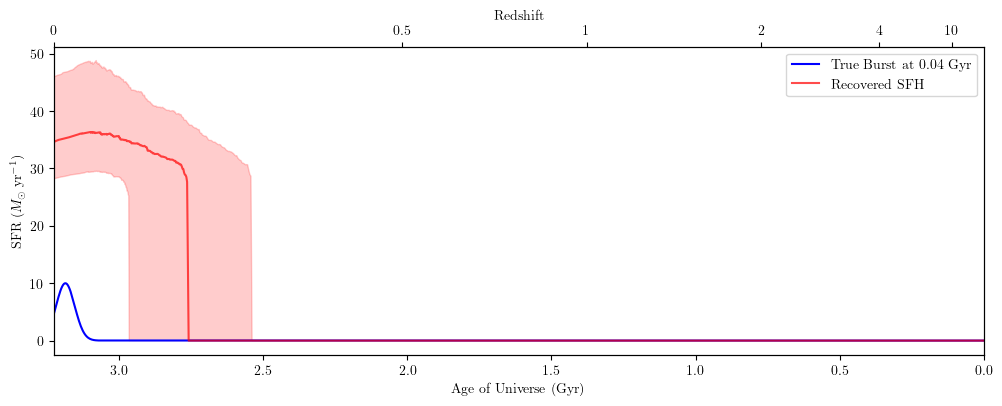

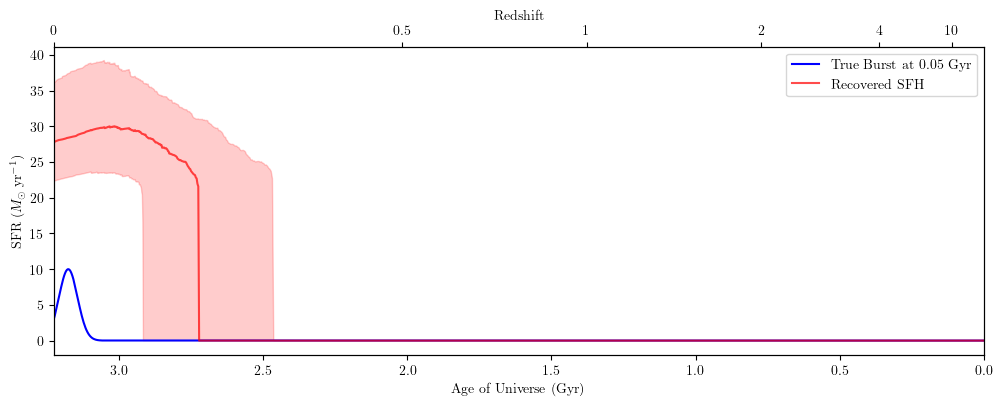

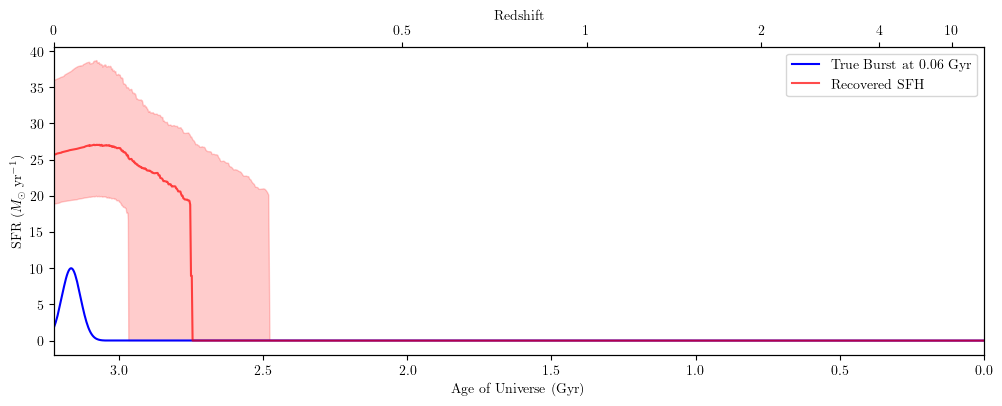

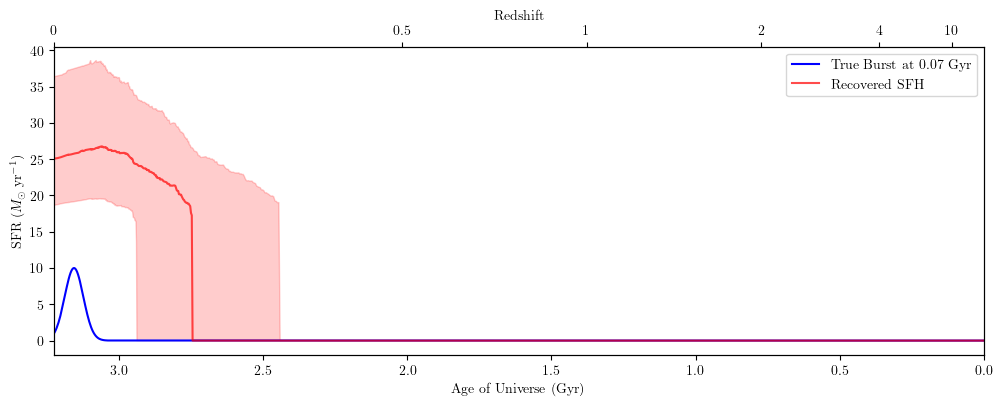

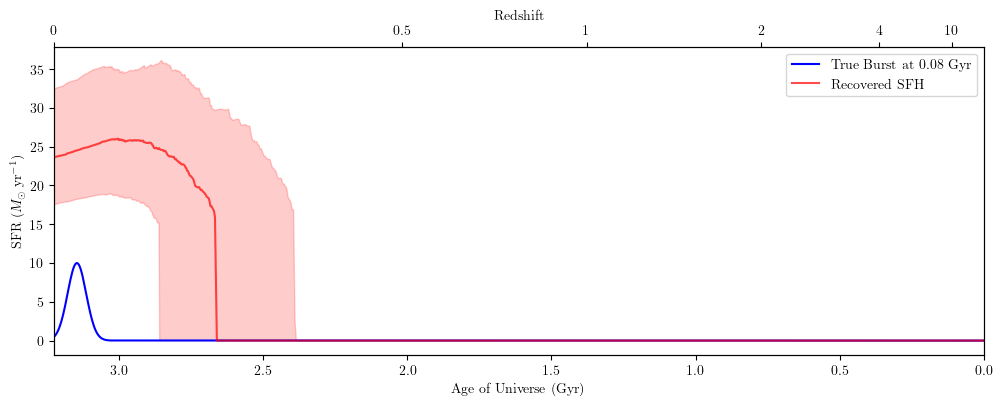

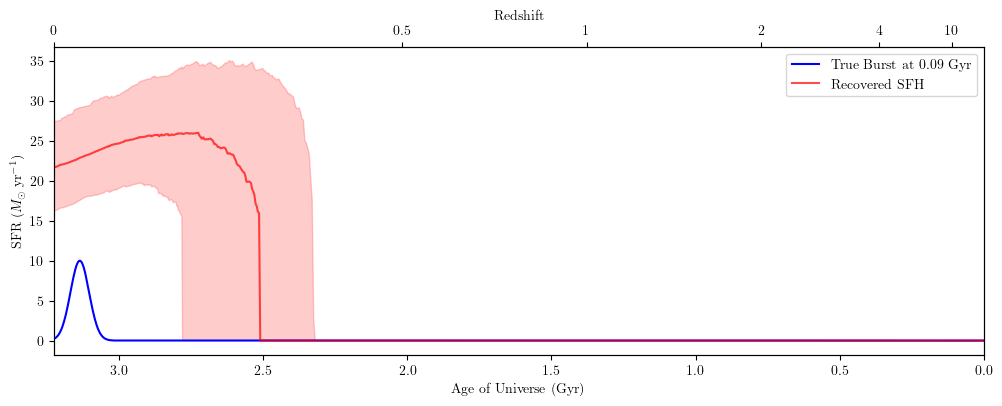

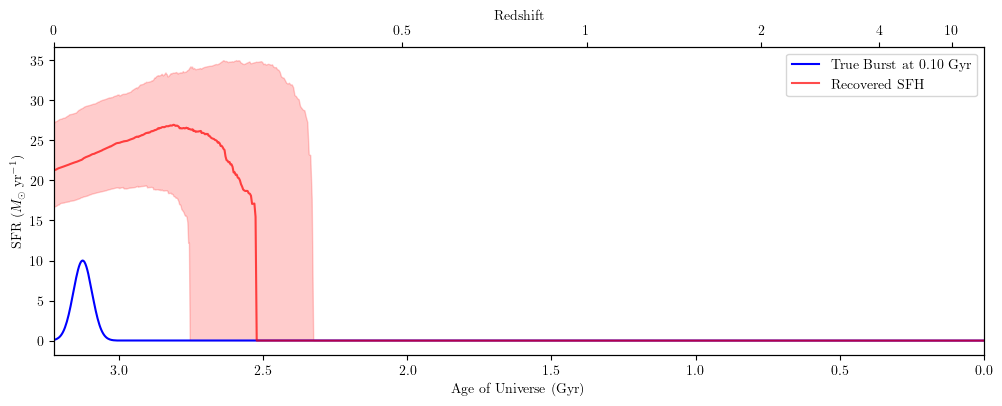

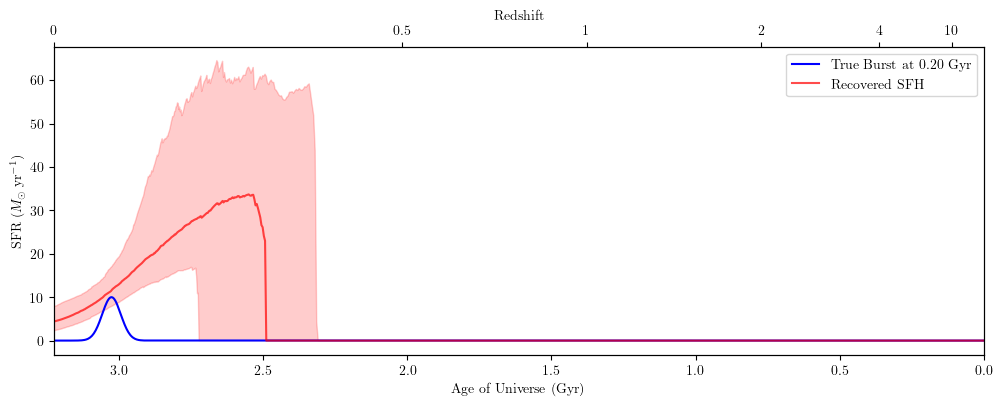

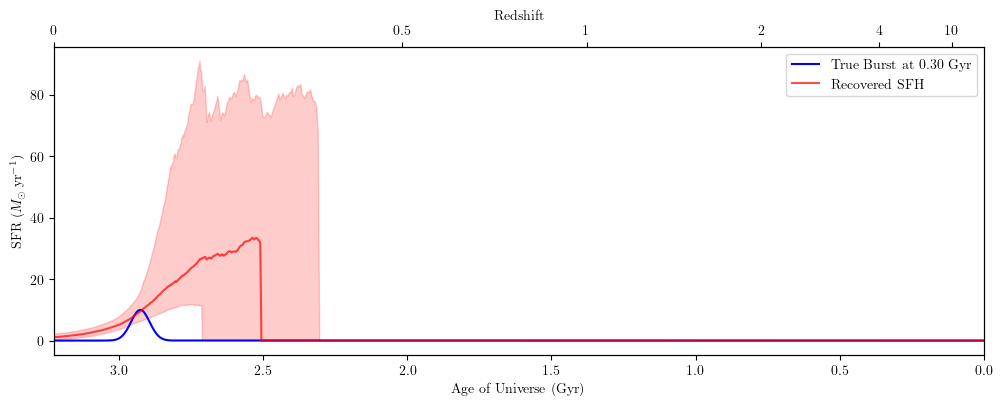

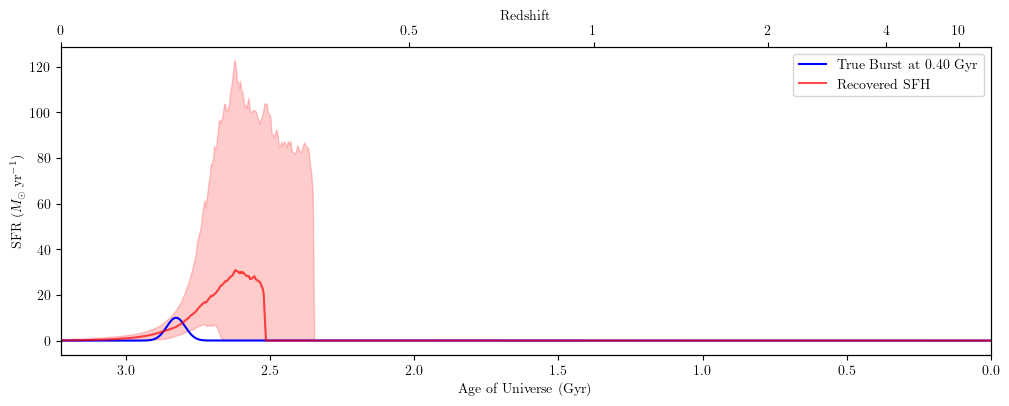

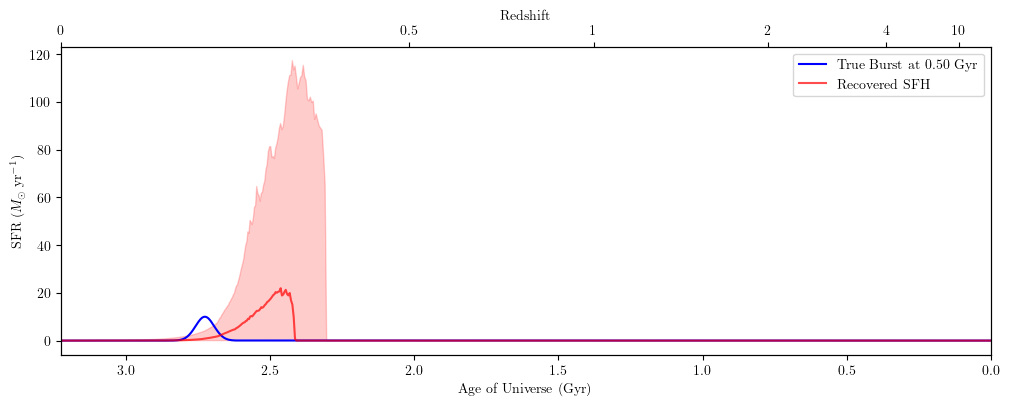

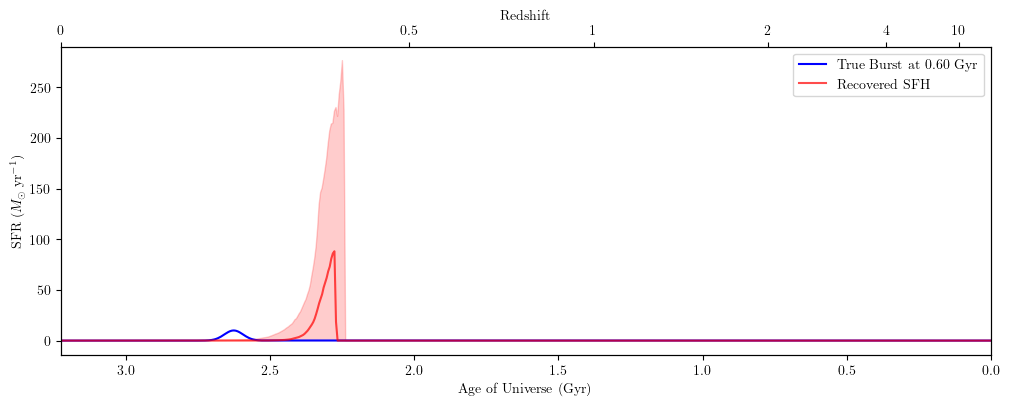

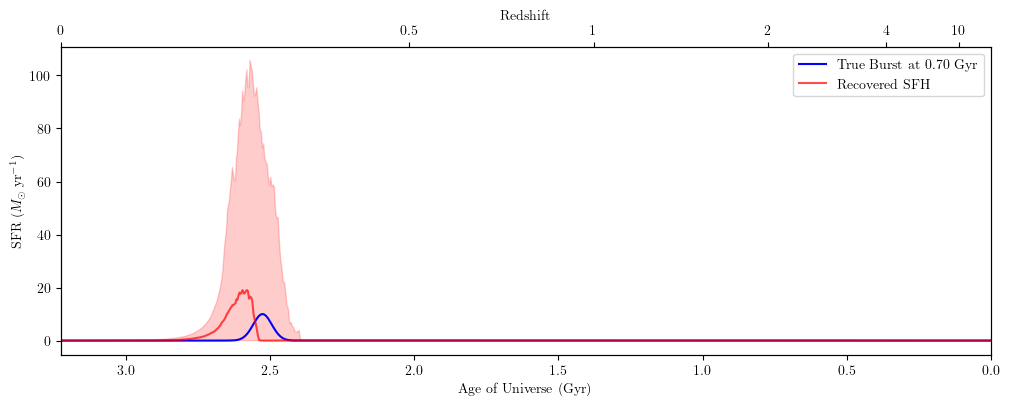

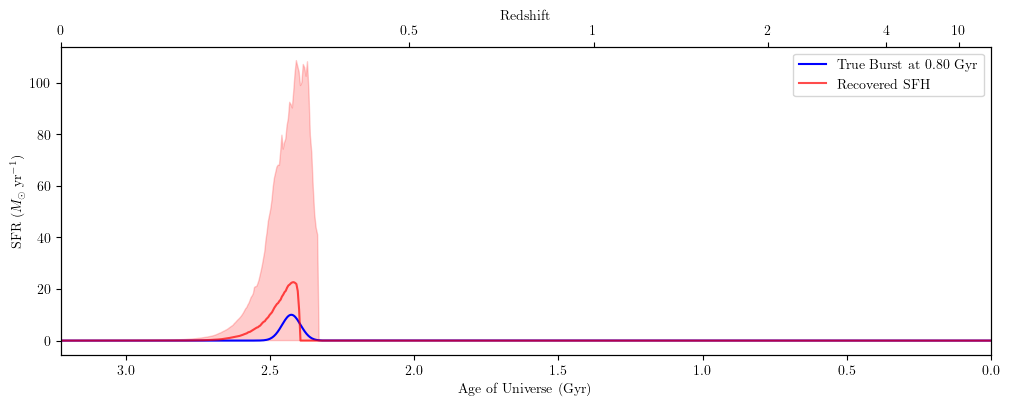

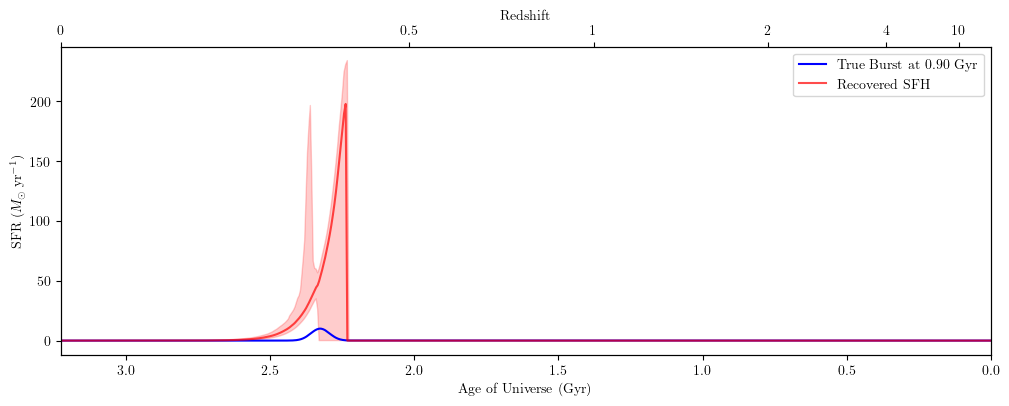

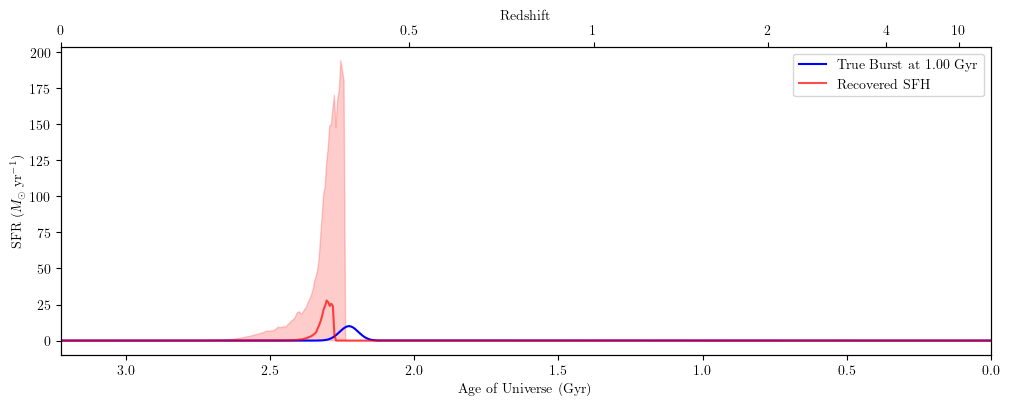

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

# Model parameters
z_model = 2       
massformed = 10  

for i, burst_age in enumerate(years):
    
    age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)
    
    n_bins = 1000
    ages_array = np.linspace(0, age_of_universe, n_bins)
    
    sigma = (ages_array.max() - ages_array.min()) * 0.01
    burst_center = age_of_universe - burst_age
    sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))
    
    fig, ax = plt.subplots(figsize=(12,4))
    
    # Plot synthetic burst
    ax.plot(ages_array, sfr_array, color="blue", label=f"True Burst at {burst_age:.2f} Gyr")
    
    # Plot recovered SFH posterior
    fit = fits[i]
    
    if "redshift" in fit.fitted_model.params:
        z_fit = np.median(fit.posterior.samples["redshift"])
    else:
        z_fit = fit.fitted_model.model_components["redshift"]
    
    age_of_universe_fit = np.interp(z_fit, utils.z_array, utils.age_at_z)
    
    post = np.percentile(fit.posterior.samples["sfh"], (16,50,84), axis=0).T
    x = age_of_universe_fit - fit.posterior.sfh.ages*1e-9 
    
    ax.plot(x, post[:,1], color="red", alpha=0.7, label="Recovered SFH")
    ax.fill_between(x, post[:,0], post[:,2], color="red", alpha=0.2)
    
    ax.set_xlim(age_of_universe, 0)
    ax.set_xlabel("Age of Universe (Gyr)")
    ax.set_ylabel(r"SFR ($M_\odot\,\mathrm{yr}^{-1}$)")
    ax.legend()
    
    ax_top = ax.twiny()
    zvals = [0,0.5,1,2,4,10]
    ages_top = np.interp(zvals, utils.z_array, utils.age_at_z)
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(ages_top)
    ax_top.set_xticklabels(zvals)
    ax_top.set_xlabel("Redshift")
    
    plt.show()

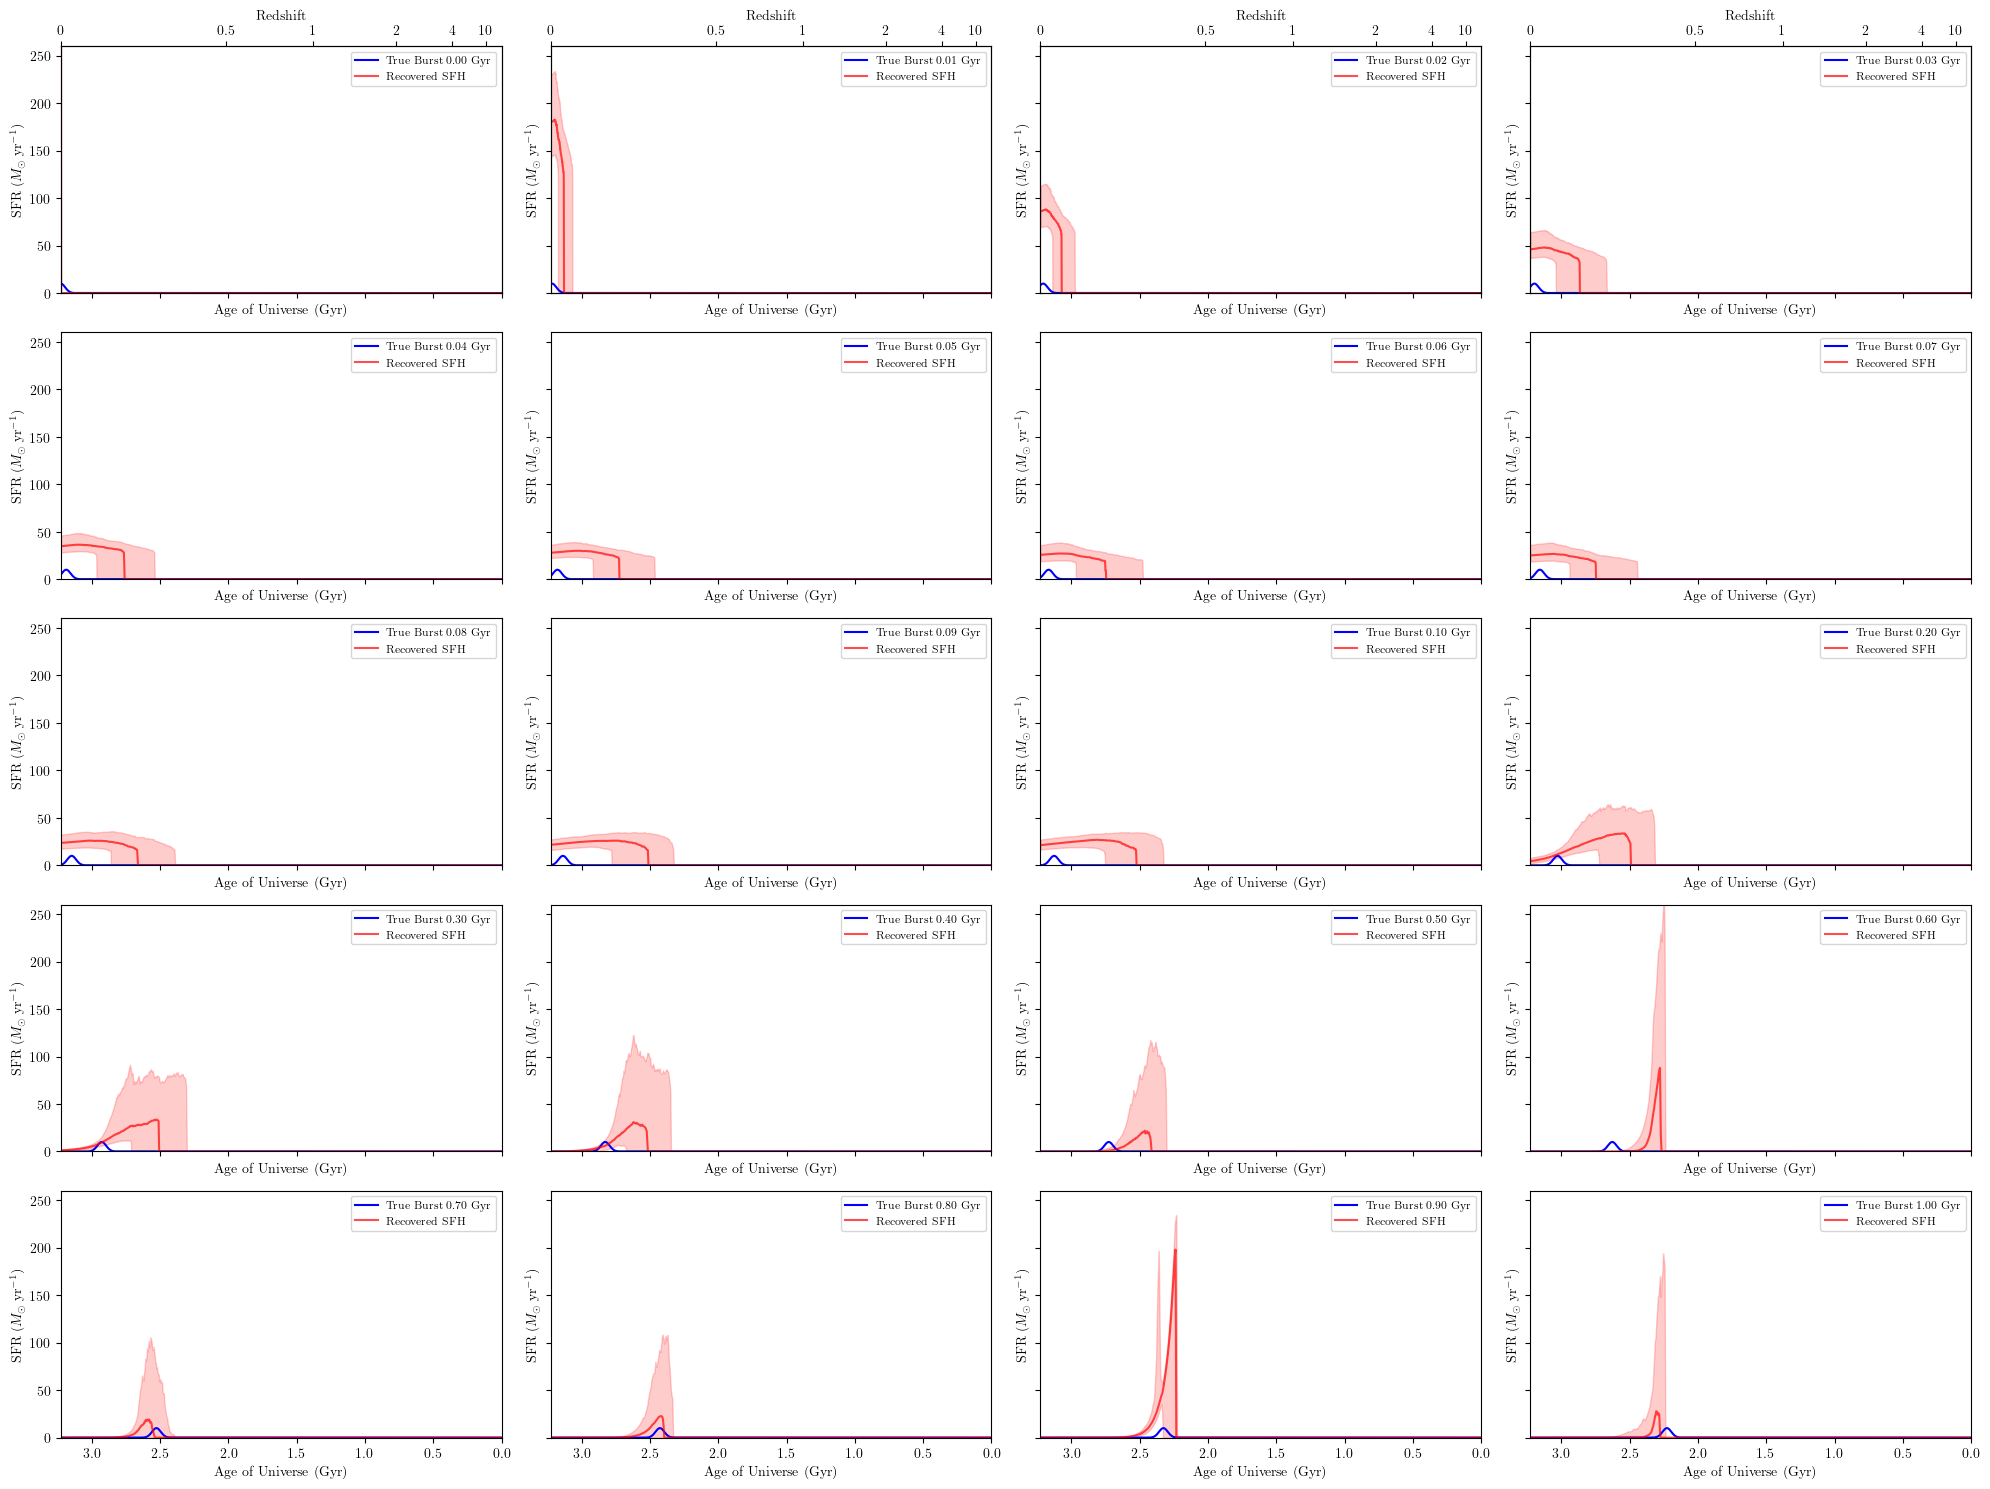

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

z_model = 2       
massformed = 10  

n_rows, n_cols = 5, 4  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()  

for i, burst_age in enumerate(years):
    
    ax = axes[i] 

    age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)
    n_bins = 1000
    ages_array = np.linspace(0, age_of_universe, n_bins)
    
    sigma = (ages_array.max() - ages_array.min()) * 0.01
    burst_center = age_of_universe - burst_age
    sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))
    
    # Plot synthetic burst
    ax.plot(ages_array, sfr_array, color="blue", label=f"True Burst {burst_age:.2f} Gyr")
    
    # Plot recovered SFH posterior
    fit = fits[i]
    
    if "redshift" in fit.fitted_model.params:
        z_fit = np.median(fit.posterior.samples["redshift"])
    else:
        z_fit = fit.fitted_model.model_components["redshift"]
    
    age_of_universe_fit = np.interp(z_fit, utils.z_array, utils.age_at_z)
    
    post = np.percentile(fit.posterior.samples["sfh"], (16,50,84), axis=0).T
    x = age_of_universe_fit - fit.posterior.sfh.ages*1e-9 
    
    ax.plot(x, post[:,1], color="red", alpha=0.7, label="Recovered SFH")
    ax.fill_between(x, post[:,0], post[:,2], color="red", alpha=0.2)
    
    ax.set_xlim(age_of_universe, 0)
    ax.set_ylim(0, 260)
    ax.set_xlabel("Age of Universe (Gyr)")
    ax.set_ylabel(r"SFR ($M_\odot\,\mathrm{yr}^{-1}$)")
    ax.legend(fontsize=8)
    
    if i < n_cols:
        ax_top = ax.twiny()
        zvals = [0,0.5,1,2,4,10]
        ages_top = np.interp(zvals, utils.z_array, utils.age_at_z)
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(ages_top)
        ax_top.set_xticklabels(zvals)
        ax_top.set_xlabel("Redshift")

for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

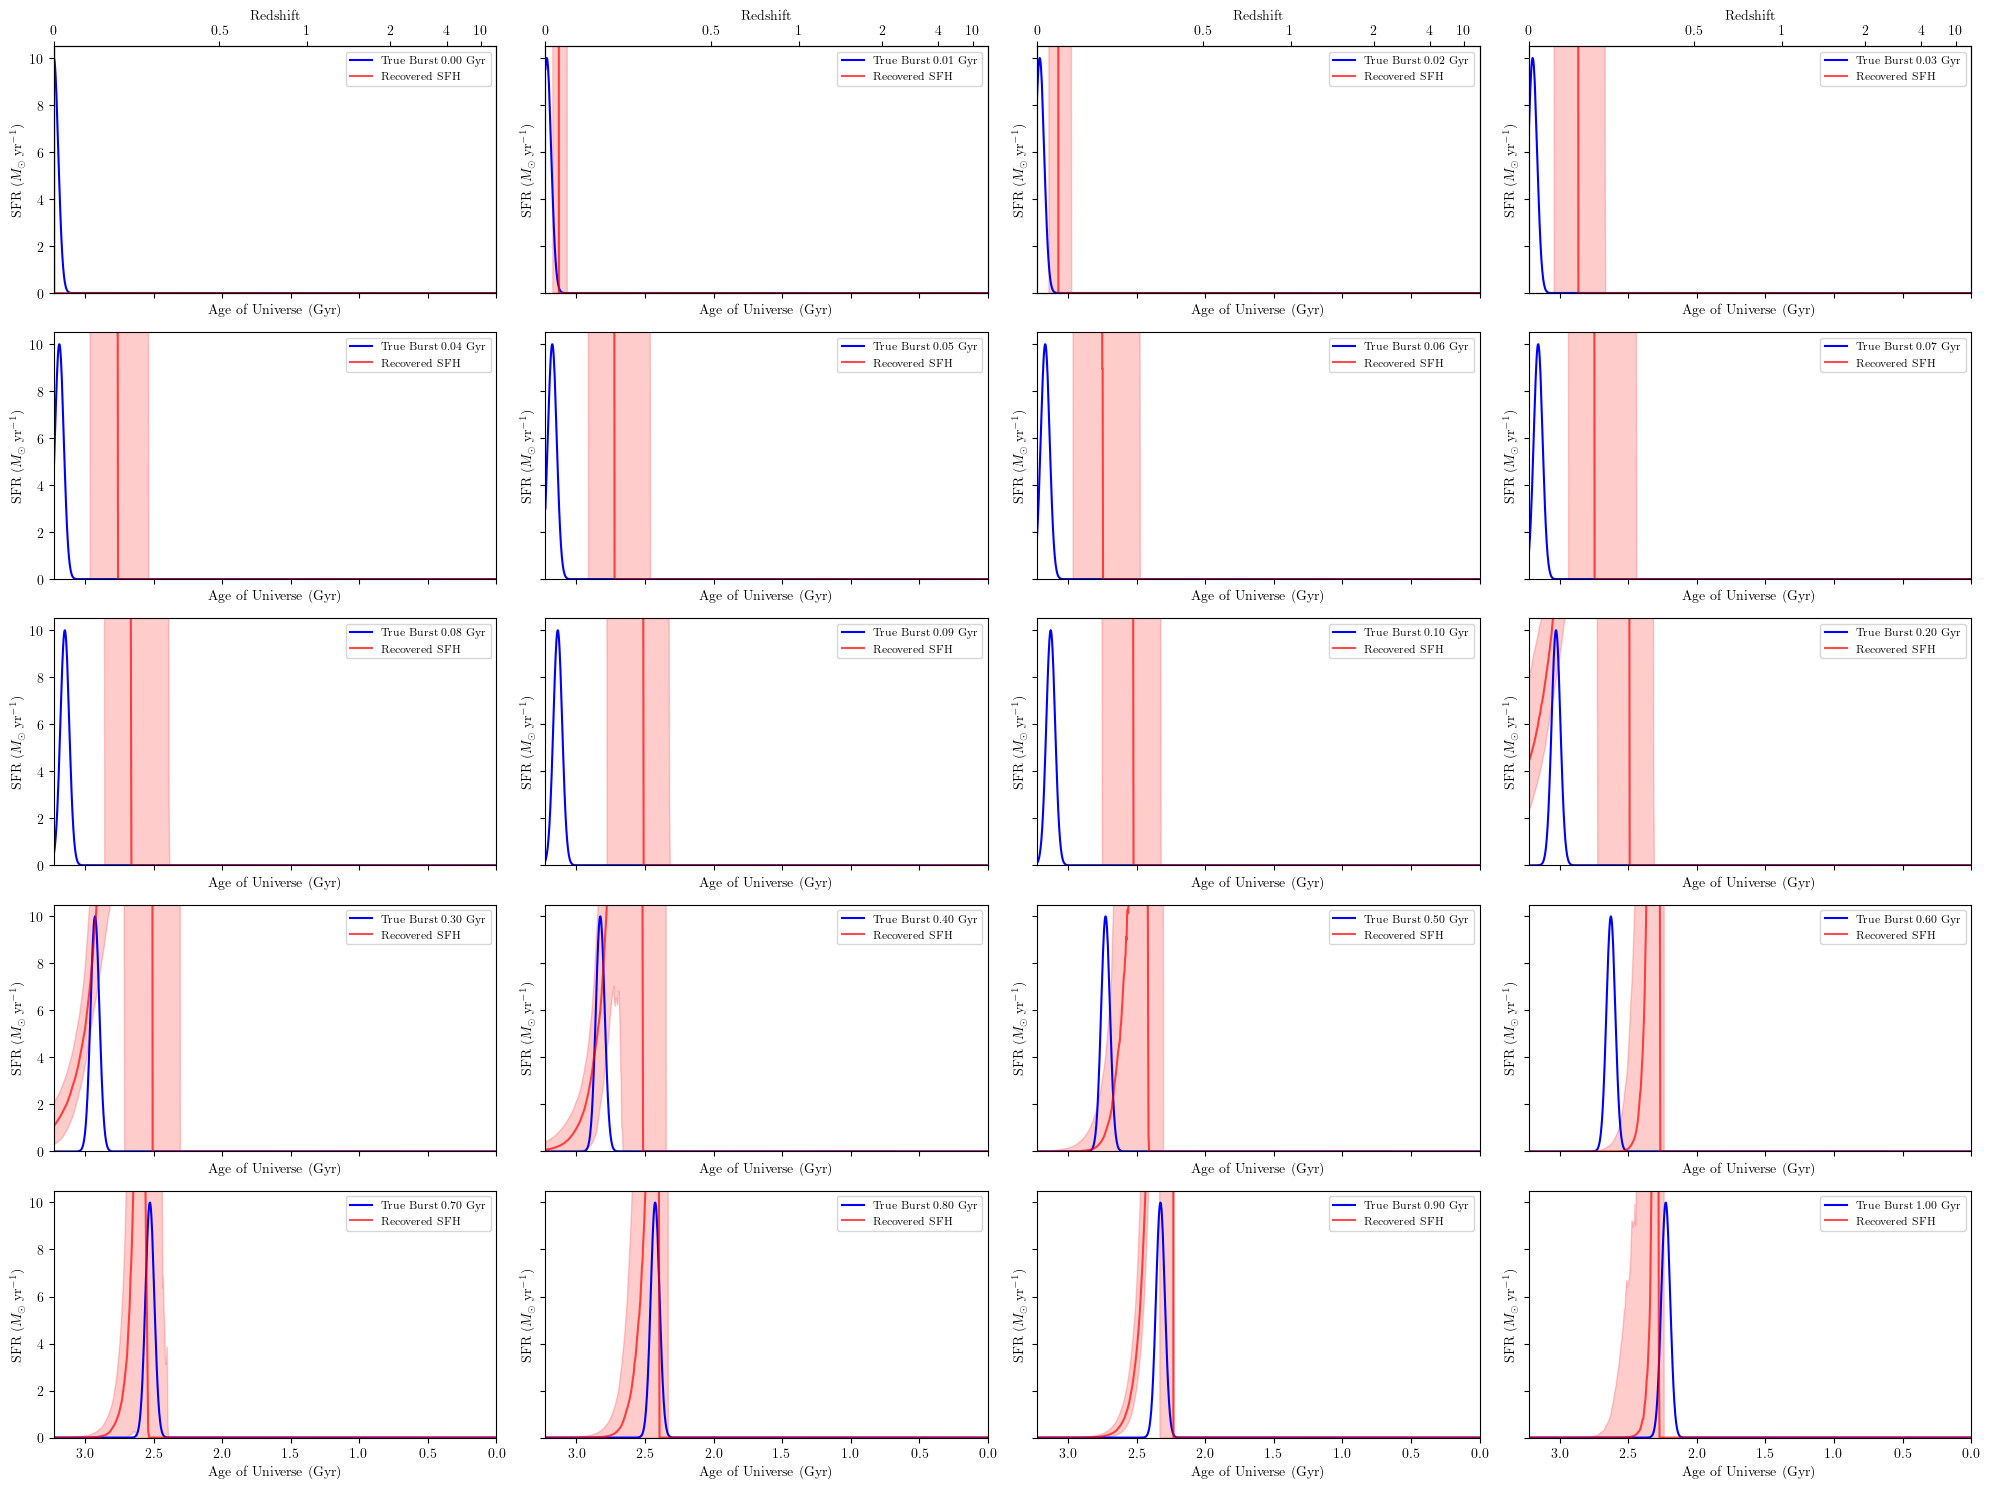

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from bagpipes import utils

z_model = 2       
massformed = 10  

n_rows, n_cols = 5, 4  
n_bins = 1000

# First, compute the maximum SFR across all bursts
max_sfr = 0
for burst_age in years:
    age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)
    ages_array = np.linspace(0, age_of_universe, n_bins)
    sigma = (ages_array.max() - ages_array.min()) * 0.01
    burst_center = age_of_universe - burst_age
    sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))
    max_sfr = max(max_sfr, sfr_array.max())

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, burst_age in enumerate(years):
    
    ax = axes[i]
    age_of_universe = np.interp(z_model, utils.z_array, utils.age_at_z)
    ages_array = np.linspace(0, age_of_universe, n_bins)
    sigma = (ages_array.max() - ages_array.min()) * 0.01
    burst_center = age_of_universe - burst_age
    sfr_array = massformed * np.exp(-(ages_array - burst_center)**2 / (2 * sigma**2))
    
    # Plot synthetic burst
    ax.plot(ages_array, sfr_array, color="blue", label=f"True Burst {burst_age:.2f} Gyr")
    
    # Plot recovered SFH posterior
    fit = fits[i]
    
    if "redshift" in fit.fitted_model.params:
        z_fit = np.median(fit.posterior.samples["redshift"])
    else:
        z_fit = fit.fitted_model.model_components["redshift"]
    
    age_of_universe_fit = np.interp(z_fit, utils.z_array, utils.age_at_z)
    
    post = np.percentile(fit.posterior.samples["sfh"], (16,50,84), axis=0).T
    x = age_of_universe_fit - fit.posterior.sfh.ages*1e-9 
    
    ax.plot(x, post[:,1], color="red", alpha=0.7, label="Recovered SFH")
    ax.fill_between(x, post[:,0], post[:,2], color="red", alpha=0.2)
    
    ax.set_xlim(age_of_universe, 0)
    ax.set_ylim(0, max_sfr*1.05)  # scale all y-axes to the global max SFR + 5% buffer
    ax.set_xlabel("Age of Universe (Gyr)")
    ax.set_ylabel(r"SFR ($M_\odot\,\mathrm{yr}^{-1}$)")
    ax.legend(fontsize=8)
    
    if i < n_cols:
        ax_top = ax.twiny()
        zvals = [0,0.5,1,2,4,10]
        ages_top = np.interp(zvals, utils.z_array, utils.age_at_z)
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(ages_top)
        ax_top.set_xticklabels(zvals)
        ax_top.set_xlabel("Redshift")

for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()